In [9]:
import spacy
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
# 1. NLP модель spaCy
nlp = spacy.load("en_core_web_sm")

# 2. Вхідний текст
# G.W. Leibniz, Letter to Foucher (1675) 
text = """I AGREE WITH YOU that it is important once and for all to examine all 
of our assumptions in order to establish something solid. For I hold that it is 
only when we can prove everything we assert that we understand perfectly 
the thing under consideration. I know that such studies are not popular with 
the common people, but I also know that the common people do not take the 
trouble to understand things at their deepest level. Your aim, so far as I can 
see, is to examine all the truths which affirm that there is something outside 
of us. You seem to be quite fair in this enterprise, for you grant us all the 
hypothetical truths which affirm, not that there is something outside of us, 
but only what would happen if there were things outside of us. Thus we 
already save arithmetic, geometry, and a large number of propositions of 
metaphysics, physics, and morality, propositions whose proper expression 
depends on arbitrarily chosen definitions, and whose truth depends on axioms 
which I commonly call identities, such as, for example, that two contradictories cannot both be, that a thing is what it is at a given time—that it is, for 
example, as large as it is, or equal to itself, that it is similar to itself, etc. 
But although you quite deliberately do not enter into an examination of 
hypothetical propositions, I am, nevertheless, of the opinion that this should 
be done and that we should not admit any that have not been demonstrated 
completely and resolved into identities. 
The principal subject of your inquiry concerns the truths that deal with 
what is really outside of us. Now, in the first place, we cannot deny that the 
very truth of hypothetical propositions is something outside of us, something 
that does not depend on us. For all hypothetical propositions assert what 
would be or what would not be if something or its contrary were posited; and 
consequently, they assert that the simultaneous assumption of two things in 
agreement with one another is possible or impossible, necessary or indifferent, 
or they assert that one single thing is possible or impossible, necessary or 
indifferent. This possibility, impossibility, or necessity (for the necessity of 
something is the impossibility of its contrary) is not a chimera we create, since 
we do nothing more than recognize it, in spite of ourselves and in a consistent 
manner. Thus of all things that there actually are, the very possibility or 
impossibility of being is the first. Now, this possibility or this necessity forms 
or composes what we call the essences or natures and the truths we commonly 
call eternal—and we are right to call them so, for there is nothing so eternal 
as that which is necessary. Thus the nature of the circle with its properties is 
something existent and eternal. That is, there is a constant cause outside us 
which makes everyone who thinks carefully about the circle discover the same 
thing. It is not merely that their thoughts agree with each other, which could 
be attributed solely to the nature of the human mind, but even the phenomena 
or experiences confirm these eternal truths when the appearance of a circle 
strikes our senses. And these phenomena necessarily have some cause outside 
of us. 
But even though the existence of necessities is the first of all truths in and 
of itself and in the order of nature, I agree that it is not first in the order of 
our knowledge. For you see, in order to prove their existence I took it for 
granted that we think and that we have sensations. Thus there are two absolute 
general truths, that is, two absolute general truths which speak of the actual 
existence of things: the first, that we think, and the second, that there is a 
great variety in our thoughts. From the former it follows that we exist, and 
from the latter it follows that there is something else besides us, that is, 
something else besides that which thinks, something which is the cause of the 
variety of our appearances. Now one of these two truths is just as incontestable 
and as independent as the other; and Descartes, having accepted only the 
former, failed to arrive at the perfection to which he had aspired in the course 
of his meditations. If he had followed precisely what I call the thread of 
meditating [fdum meditandib I believe that he would have achieved the first 
philosophy. But not even the world's greatest genius can force things, and we 
must necessarily enter through the entryways that nature has made, so that 
we do not stray. Moreover, one person alone cannot do everything at once, 
and for myself, when I think of everything Descartes has said that is beautiful 
and original, I am more astonished with what he has accomplished than with 
what he has failed to accomplish. I admit that I have not yet been able to read 
all his writings with all the care I had intended to bring to them, and my 
friends know that, as it happened, I read almost all the new philosophers 
before reading him. Bacon and Gassendi were the first to fall into my hands; 
their familiar and easy style was better adapted to a person who wants to read 
everything. It is true that I often glanced at Galileo and Descartes, but since 
I became a geometer only recently, I was soon repelled by their manner of 
writing, which requires deep meditation. As for myself, although I always 
liked to meditate, I always found it difficult to read books that cannot be 
understood without much meditation. For, when following one's own meditations one follows a certain natural inclination and gains profit along with 
pleasure; but one is enormously cramped when having to follow the meditations of others. I always liked books that contained some fine thoughts, but 
books that one could read without stopping, for they aroused ideas in me 
which I could follow at my fancy and pursue as I pleased. This also prevented 
me from reading geometry books with care, and I must admit that I have not 
LETI'ER To FouctIER 3 
yet brought myself to read Euclid in any other way than one commonly reads 
novels [histoires]. I have learned from experience that this method in general 
is a good one; but I have learned nevertheless that there are authors for 
whom one must make an exception—Plato and Aristotle among the ancient 
philosophers and Galileo and Descartes among ours. Yet what I know of 
Descartes's metaphysical and physical meditations is almost entirely derived 
from reading a number of books, written in a more familiar style, that report 
his opinions. So perhaps I have not yet understood him well. However, to 
the extent that I have leafed through his works myself, it seemed to me that 
I have glimpsed at very least what he has not accomplished and not even 
attempted to accomplish, that is, among other things, the analysis of all our 
assumptions. That is why I am inclined to applaud all those who examine the 
least truth to its deepest level; for I know that it is important to understand 
one perfectly, however small and however easy it may seem. This is the way 
to progress quite far and finally to establish the art of discovery which depends 
on a knowledge, but a most distinct and perfect knowledge of the easiest 
things. And for this reason I found nothing wrong in Roberval's attempt to 
demonstrate everything in geometry, including some axioms.' I admit that 
we should not demand such exactness from others, but I believe that it is 
good to demand it from ourselves. 
I return to those truths, from among those asserting that there is something 
outside us, which are first with respect to ourselves, namely, that we think 
and that there is a great variety in our thoughts. Now, this variety cannot 
come from that which thinks, since a single thing by itself cannot be the cause 
of the changes in itself. For everything would remain in the state in which it 
is, if there is nothing that changes it; and since it did not determine itself to 
have these changes rather than others, one cannot begin to attribute any 
variety to it without saying something which, we must admit, has no reason—
which is absurd. And even if we tried to say that our thoughts had no 
beginning, beside the fact that we would be required to assert that each of us 
has existed from all eternity, we would still not escape the difficulty; for we 
would always have to admit that there is no reason for the particular variety 
which would have existed in our thoughts from all eternity, since there is 
nothing in us that determines us to have one kind of variety rather than to 
another. Therefore there is some cause outside of us for the variety of our 
thoughts. And since we conceive that there are subordinate causes for this 
variety, causes which themselves still need causes, we have established particular beings or substances certain of whose actions we recognize, that is, things 
from whose changes we conceive certain changes in us to follow. And we 
quickly proceed to construct what we call matter and body. But it is at this 
point that you are right to stop us a bit and renew the criticisms of the ancient 
Academy. For, at bottom, all our experience assures us of only two things, 
9. Roberval does attempt to demonstrate Euclid's axioms in his Elements of Geometry, one of namely, that there is a connection among our appearances which provides us 
the means to predict future appearances with success, and that this connection 
must have a constant cause. But it does not strictly follow from all this that 
matter or bodies exist, but only that there is something that presents wellsequenced appearances to us. For if an invisible power took pleasure in giving 
us dreams that are well connected with our preceding life and in conformity 
among themselves, could we distinguish them from realities before having 
been awakened? And what prevents the course of our life from being a long 
well-ordered dream, a dream from which we could be wakened in a moment? 
And I do not see that this power would be imperfect on that account, as 
Descartes asserts, leaving aside the fact that it does not matter if it is imperfect. 
For this could be a certain subordinate power, or some genie who meddles in 
our affairs for some unknown reason and who has as much power over 
someone as had the caliph who transported a drunken man into his palace 
and made him taste of Mohammed's paradise when he had awakened; after 
this he was made drunk again and was returned to the place from which he 
had been taken. And when the man came to himself, he did not fail to interpret 
what to him appeared inconsistent with the course of his life as a vision, and 
spread among the people maxims and revelations that he believed he had 
learned in his pretended paradise—this was what the caliph wished. Now, 
since a reality passed for a vision, what prevents a vision from passing for a 
reality? It is true that the more we see some connection in what happens to 
us, the more we are confirmed in the opinion we have about the reality of our 
appearances; and it is also true that the more we examine our appearances 
closely, the more we find them well-sequenced, as microscopes and other aids 
in making experiments have shown us. This constant accord engenders great 
assurance, but after all, it will only be moral assurance until somebody discovers the a priori origin of the world we see and pursues the question as to 
why things are the way they appear back to the ground of essence. For having 
done that, he will have demonstrated that what appears to us is a reality and 
that it is impossible that we ever be deceived about it again. But I believe that 
this would nearly approach the beatific vision and that it is difficult to aspire 
to this in our present state. However, we would learn from this how confused 
the knowledge we commonly have of body and matter must be, since we 
believe we are certain they exist but in the end we discover that we can be 
mistaken. And this confirms Descartes's excellent proof of the distinction 
between body and soul, since we can doubt the former without being able to 
put the latter into question. For even if there were only appearances or 
dreams, we would be no less certain of the existence of that which thinks, as 
Descartes has said quite nicely. I add that the existence of God can be 
demonstrated in ways other than Descartes did, ways which, I believe, bring 
us farther along. For we do not need to assume a being who guarantees us 
against being deceived, since it is in our power to undeceive ourselves about 
many things, at least about the most important ones. I wish, sir, that your 
meditations on this have all the success you desire. But to accomplish this, it 
is good to proceed in order and to establish propositions; that is the way to 
gain ground and to make sure progress. 1 believe that you would oblige the 
public by conveying to it, from time to time, selections from the Academy 
and especially from Plato, for I recognize that there are things in there more 
beautiful and solid than commonly thought. 
"""

# René Descartes, Rule 7
text1 = """If we wish our science to be complete, those 
matters which promote the end we have in view 
must one and all be scrutinized by a movement 
of thought which is continuous and nowhere 
interrupted; they must also be included in an 
enumeration which is both adequate and 
methodical.
I
t is necessary to obey the injunctions of this 
rule if we hope to gain admission among 
the certain truths for those which, we have 
declared above, are not immediate deductions 
from primary and self-evident principles. For 
this deduction frequently involves such a long 
series of transitions from ground to consequent 
The Philosophical Works of Descartes 57
that when we come to the conclusion we have 
difficulty in recalling the whole of the route by 
which we have arrived at it. This is why I say 
that there must be a continuous movement 
of thought to make good this weakness of the 
memory. Thus, e.g. if I have first found out by 
separate mental operations what the relation 
is between the magnitudes A and B, then 
what between B and C, between C and D, and 
finally between D and E, that does not entail 
my seeing what the relation is between A and 
E, nor can the truths previously learnt give me 
a precise knowledge of it unless I recall them 
all. To remedy this I would run them over from 
time to time, keeping the imagination moving 
continuously in such a way that while it is 
intuitively perceiving each fact it simultaneously 
passes on to the next; and this I would do until 
I had learned to pass from the first to the last so 
quickly, that no stage in the process was left to 
the care of the memory, but I seemed to have 
the whole in intuition before me at the same 
The Philosophical Works of Descartes 58
time. This method will both relieve the memory, 
diminish the sluggishness of our thinking, and 
definitely enlarge our mental capacity.
But we must add that this movement should 
nowhere be interrupted. Often people who 
attempt to deduce a conclusion too quickly and 
from remote principles do not trace the whole 
chain of intermediate conclusions with sufficient 
accuracy to prevent them from passing over 
many steps without due consideration. But it 
is certain that wherever the smallest link is left 
out the chain is broken and the whole of the 
certainty of the conclusion falls to the ground.
Here we maintain that an enumeration [of 
the steps in a proof] is required as well, if 
we wish to make our science complete. For 
resolving most problems other precepts are 
profitable, but enumeration alone will secure 
our always passing a true and certain judgment 
on whatsoever engages our attention; by 
means of it nothing at all will escape us, but we 
20
The Philosophical Works of Descartes 59
shall evidently have some knowledge of every 
step.
This enumeration or induction is thus a 
review or inventory of all those matters that 
have a bearing on the problem raised, which 
is so thorough and accurate that by its means 
we can clearly and with confidence conclude 
that we have omitted nothing by mistake. 
Consequently as often as we have employed 
it, if the problem defies us, we shall at least 
be wiser in this respect, viz. that we are quite 
certain that we know of no way of resolving it. 
If it chance, as often it does, that we have been 
able to scan all the routes leading to it which 
lie open to the human intelligence, we shall be 
entitled boldly to assert that the solution of 
the problem lies outside the reach of human 
knowledge.
Furthermore we must note that by 
adequate enumeration or induction is only 
meant that method by which we may attain 
surer conclusions than by any other type of 
The Philosophical Works of Descartes 60
proof, with the exception of simple intuition. 
But when the knowledge of some matter 
cannot be reduced to this, we must cast aside 
all syllogistic fetters and employ induction, 
the only method left us, but one in which all 
confidence should be reposed. For whenever 
single facts have been immediately deduced 
the one from the other, they have been already 
reduced, if the inference was evident, to a 
true intuition. But if we infer any single thing 
from various and disconnected facts, often our 
intellectual capacity is not so great as to be 
able to embrace them all in a single intuition; 
in which case our mind should be content 
with the certitude attaching to this operation. 
It is in precisely similar fashion that though we 
cannot with one single gaze distinguish all the 
links of a lengthy chain, yet if we have seen the 
connection of each with its neighbour, we shall 
be entitled to say that we have seen how the 
first is connected with the last.
21
The Philosophical Works of Descartes 61
I have declared that this operation ought to 
be adequate, because it is often in danger of 
being defective and consequently exposed 
to error. For sometimes, even though in our 
enumeration we scrutinize many facts which 
are highly evident, yet if we omit the smallest 
step the chain is broken and the whole of the 
certitude of the conclusion falls to the ground. 
Sometimes also, even though all the facts are 
included in an accurate enumeration, the single 
steps are not distinguished from one another, 
and our knowledge of them all is thus only 
confused.
Further, while now the enumeration ought 
to be complete, now distinct, there are times 
when it need have neither of these characters; 
it was for this reason that I said only that it 
should be adequate. For if I want to prove by 
enumeration how many genera there are of 
corporeal things, or of those that in any way fall 
under the senses, I shall not assert that they are 
just so many and no more, unless I previously 
The Philosophical Works of Descartes 62
have become aware that I have included them 
all in my enumeration, and have distinguished 
them each separately from all the others. But if 
in the same way I wish to prove that the rational 
soul is not corporeal, I do not need a complete 
enumeration; it will be sufficient to include all 
bodies in certain collections in such a way as to 
be able to demonstrate that the rational soul 
has nothing to do with any of these. If, finally, 
I wish to show by enumeration that the area 
of a circle is greater than the area of all other 
figures whose perimeter is equal, there is no 
need for me to call in review all other figures; 
it is enough to demonstrate this of certain 
others in particular, in order to get thence by 
induction26 the same conclusion about all the 
others.
I added also that the enumeration ought 
to be methodical. This is both because we 
have no more serviceable remedy for the 
defects already instanced, than to scan all 
26. This seems to be a different sense of the word ‘inductio’ from that above.
The Philosophical Works of Descartes 63
things in an orderly manner; and also because 
it often happens that if each single matter 
which concerns the quest in hand were to be 
investigated separately, no man’s life would 
be long enough for the purpose, whether 
because they are far too many, or because it 
would chance that the same things had to be 
repeated too often. But if all these facts are 
arranged in the best order, they will for the 
most part be reduced to determinate classes, 
out of which it will be sufficient to take one 
example for exact inspection, or some one 
feature in a single case, or certain things rather 
than others, or at least we shall never have to 
waste our time in traversing the same ground 
twice. The advantage of this course is so great 
that often many particulars can, owing to a well 
devised arrangement, be gone over in a short 
space of time and with little trouble, though at 
first view the matter looked immense.
But this order which we employ in our 
enumerations can for the most part be varied 
22
The Philosophical Works of Descartes 64
and depends upon each man’s judgment. For this 
reason, if we would elaborate it in our thought 
with greater penetration, we must remember 
what was said in our fifth proposition27. There 
are also many of the trivial things of man’s 
devising, in the discovery of which the whole 
method lies in the disposal of this order. Thus 
if you wish to construct a perfect anagram by 
the transposition of the letters of a name, there 
is no need to pass from the easy to the difficult, 
nor to distinguish absolute from relative. Here 
there is no place for these operations; it will be 
sufficient to adopt an order to be followed in 
the transpositions of the letters which we are to 
examine, such that the same arrangements are 
never handled twice over. The total number 
of transpositions should, e.g. be split up into 
definite classes, so that it may immediately 
appear in which there is the best hope of 
finding what is sought. In this way the task is 
often not tedious but merely child’s play.
27. Cf. p. 14.
The Philosophical Works of Descartes 65
However, these three propositions should 
not be separated, because for the most part 
we have to think of them together, and all 
equally tend towards the perfecting of our 
method. There was no great reason for treating 
one before the other, and we have expounded 
them but briefly here. The reason for this is that 
in the rest of the treatise we have practically 
nothing else left for consideration. Therefore 
we shall then exhibit in detail what here we 
have brought together in a general way.
"""

# Immanuel Kant, Critique of Pure Reason, The Transcendental Doctrine of Elements First Part 
text1 = """In whatever way and through whatever means a cognition may relate to 
objects, that through which it relates immediately to them, and at which 
all thought as a means is directed as an end, is intuition. This, however, 
takes place only insofar as the object is given to us; but this in turn, <at 
least for us humans,> is possible only if it affects the mind in a certain 
way. The capacity (receptivity) to acquire representations through the 
way in which we are affected by objects is called sensibility. Objects are 
therefore given to us by means of sensibility, and it alone affords us intuitions; but they are thought through the understanding, and from it 
arise concepts. But all thought, whether straightaway (directe) or 
through a detour (indirecte), must, <by means of certain marks,> ultimately be related to intuitions, thus, in our case, to sensibility, since 
there is no other way in which objects can be given to us. 
B 34 The effect of an object on the capacity for representation, insofar as 
A20 we are affected by it, is sensation. That intuition which is related to the 
object through sensation is called empirical. The undetermined object 
of an empirical intuition is called appearance. 
I call that in the appearance which corresponds to sensation its matter, but that which allows the manifold of appearance to be orderedc in 
a We here present the revised version of the "Transcendental Aesthetic" that Kant prepared for the second edition of the Critique. Since in addition to the major changes that 
he made, all of which will be noted, Kant also made numerous minor changes that it 
would be cumbersome to note individually, we will enclose all the changes Kant made 
in B within angled brackets « . . . », whether or not they are otherwise noted. Editorial 
notes on passages unchanged from A will not be repeated. 
b In the second edition, Kant divided the "Transcendental Doctrine of Elements" from 
the beginning of the "Transcendental Aesthetic" through the end of the "Transcendental Deduction of the Pure Concepts of the Understanding" into twenty-seven numbered sections. In the case of some sections, new titles were also added for material 
otherwise taken over without other change from the first edition. 
, In the first edition this reads "intuited as ordered in certain relations ... " 
The Transcendental Aesthetic <B> 
certain relationsa I call the form of appearance. Since that within which 
the sensations can alone be ordered and placed in a certain form cannot 
itself be in turn sensation, the matter of all appearance is only given to 
us a posteriori, but its form must all lie ready for it in the mind a priori, 
and can therefore be considered separately from all sensation. 
I call all representations pure (in the transcendental sense) in which 
nothing is to be encountered that belongs to sensation. Accordingly the 
pure form of sensible intuitions in general is to be encountered in the 
mind a priori, wherein all of the manifold of appearances is intuited in 
certain relations. This pure form of sensibility itself is also called pure 
intuition. So if I separate from the representation of a body that which B 3 5 
the understanding thinks about it, such as substance, force, divisibility, 
etc., as well as that which belongs to sensation, such as impenetrability, 
hardness, color, etc., something from this empirical intuition is still left A21 
for me, namely extension and form. These belong to the pure intuition, 
which occurs a priori, even without an actual object of the senses or sensation, as a mere form of sensibility in the mind. 
I call a science of all principlesb of a priori sensibility the transcendental aesthetic. * There must therefore be such a science, which constitutes the first part of the transcendental doctrine of elements, in B 36 
opposition to that which contains the principlesc of pure thinking, and 
which is named transcendental logic. 
* The Germans are the only ones who now employ the word "aesthetics" to des- A 2 I / B 35 
ignate that which others call the critique of taste. The ground for this is a failed 
hope, held by the excellent analyst Baumgarten, of bringing the critical estimation of the beautiful under principles of reason,d and elevating its rules to a science. But this effort is futile. For the putative rules or criteria are merely empirical as far as their <most prominent> sources are concerned, and can therefore 
never serve as <determinate> a priori rules according to which our judgment of 
taste must be directed; rather the latter constitutes the genuine touchstone of the 
correctness of the former. For this reason it is advisable <either> again to desist B 36 
from the use of this term and preserve it for that docu'ine which is true science 
(whereby one would come closer to the language and the sense of the ancients, 
among whom the division of cognition into CHe1JTG¥ Kat V01JTG¥ was very well 
known), <or else to share the term with speculative philosophy and take aesthetics partly in a transcendental meaning, partly in a psychological meaning>. 
a As already noted at p. 1 56, note a, with the exception of four cases in its final section, 
throughout the "Transcendental Aesthetic" Kant characteristically uses the term 
Verbaltnis, connoting a relation among objects, rather than Beziebung, connoting a relation between subject and object; thus, unless otherwise noted, "relation" or its plural 
translates Verbaltnis or its derivatives. 
b Principien 
C Principien 
d Vernunftprincipien 
173 
Doctrine of Elements. Part L The Transcendental Aesthetic <B> 
A22 In the transcendental aesthetic we will therefore first isolate sensibility by separating off everything that the understanding thinks 
through its concepts, so that nothing but empirical intuition remains. 
Second, we will then detach from the latter everything that belongs to 
sensation, so that nothing remains except pure intuition and the mere 
form of appearances, which is the only thing that sensibility can make 
available a priori. In this investigation it will be found that there are two 
pure forms of sensible intuition as principles a of a priori cognition, 
namely space and time, with the assessment of which we will now be 
concerned. 
B 37 The Transcendental Aesthetic 
First Section 
On space. 
<§ 2 
Metaphysical exposition of this concept.> 
By means of outer sense (a property of our mind) we represent to 
ourselves objects as outside us, and all as in space. In space their shape, 
magnitude, and relation to one another is determined, or determinable. 
Inner sense, by means of which the mind intuits itself, or its inner state, 
gives, to be sure, no intuition of the soul itself, as an object;h yet it is 
A 2 3 still a determinate form, under which the intuition of its inner state is 
alone possible, so that everything that belongs to the inner determinations is represented in relations of time. Time can no more be intuited 
externally than space can be intuited as something in us. Now what are 
space and time? Are they actual entities?C Are they only determinations 
or relations of things, yet ones that would pertain to them even if they 
were not intuited, or are they relations that only attach to the form of 
B 38 intuition alone, and thus to the subjective constitution of our mind, 
without which these predicates could not be ascribed to any thing at all? 
In order to instruct ourselves about this, we will <expound the concept 
of space> first.d <l understand by exposition (expositio) the distinct 
(even if not complete) representation of that which belongs to a concept; but the exposition is metaphysical when it contains that which 
exhibits the concept as given a priori. > 
I) Space is not an empirical concept that has been drawn from outer 
" Principien 
b Object 
, wirkliche Wesen 
d In the first edition: "first consider space." 
1 74 
Section 1. On Space <B> 
experiences. For in order for certain sensations to be relateda to something outside me (i.e., to something in another place in space from that 
in which I find myself), thus in order for me to represent them as outside <and next to> one another, thus not merely as different but as in 
different places, the representation of space must already be their 
ground. Thus the representation of space cannot be obtained from the 
relations of outer appearance through experience, but this outer experience is itself first possible only through this representation. 
2) Space is a necessary representation, a priori, that is the ground of A 24 
all outer intuitions. One can never represent that there is no space, 
though one can very well think that there are no objects to be encountered in it. It is therefore to be regarded as the condition of the possi- B 39 
bility of appearances, not as a determination dependent on them, and is 
an a priori representation that necessarily grounds outer appearances.b 
<3» Space is not a discursive or, as is said, general concept of relations of things in general, but a pure intuition. For, first, one can only A25 
represent a single space, and if one speaks of many spaces, one understands by that only parts of one and the same unique space. And these 
parts cannot as it were precede the single all-encompassing space as its 
components (from which its composition would be possible), but rather 
are only thought in it. It is essentially single; the manifold in it, thus 
also the general concept of spaces in general, rests merely on limitations. From this it follows that in respect to it an a priori intuition 
(which is not empirical) grounds all concepts of it.C Thus also all geometrical principles, e.g., that in a triangle two sides together are always 
greater than the third, are never derived from general concepts of line 
and triangle, but rather are derived from intuition and indeed derived a 
priori with apodictic certainty. 
<d4) Space is represented as an infinite given magnitude. Now one 
must, to be sure, think of every concept as a representation that is con- B 40 
tained in an infinite set of different possible representations (as their 
common mark), which thus contains these under itself; but no concept, as such, can be thought as if it contained an infinite set of representations within itself. Nevertheless space is so thought (for all the 
parts of space, even to infinity, are simultaneous). Therefore the original representation of space is an a priori intuition, not a concept.> 
a bezogen 
b In the first edition there follows a paragraph (3) (at A24 above) that is replaced by the 
"Transcendental Exposition of the Concept of Space" in the second (see B 40-I below); 
the following paragraphs, (3) and (4), were thus originally numbered (4) and (5); the 
content of the original paragraph (5), now renumbered (4), is also changed. 
, In the first edition: "of them," i.e., the limitations of space. 
d As previously mentioned, the content of this paragraph is changed from the first edition. 
"""

In [3]:
# 3. Лематизація
doc = nlp(text)
tokens = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and token.is_alpha
]
cleaned_text = " ".join(tokens)

In [4]:
# 4. Завантаження моделі LaBSE
model_name = "sentence-transformers/LaBSE"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# 5. Токенізація та ембединг
inputs = tokenizer(cleaned_text, return_tensors="pt", truncation=True)
with torch.no_grad():
    outputs = model(**inputs)
    token_embeddings = outputs.last_hidden_state.squeeze(0)
    
# 6. Вилучаємо ембединги без спецтокенів
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
embeddings = [
    vec.numpy()
    for token, vec in zip(tokens, token_embeddings)
    if token not in tokenizer.all_special_tokens
]
tokens_cleaned = [
    token
    for token in tokens
    if token not in tokenizer.all_special_tokens
]

In [5]:
# 7. Нормалізація векторів, обчислення центроїда і відстаней
embeddings = np.array(embeddings)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
unit_vectors = embeddings / norms

centroid = np.mean(unit_vectors, axis=0)

distances = np.linalg.norm(unit_vectors - centroid, axis=1)
radius = 5

# 8. Семантична сила через сферичну поверхню
surface_area = 4 * np.pi * (radius ** 2)
semantic_force = np.sum(distances) / surface_area

print(f"Semantic Power: {semantic_force:.4f}")

Semantic Power: 0.6010


In [6]:
# 9. Визначення оптимальної кількості кластерів за Silhouette Score
components_range = range(2, 10)
silhouette_scores = []

for n in components_range:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(unit_vectors)
    labels = gmm.predict(unit_vectors)
    score = silhouette_score(unit_vectors, labels)
    silhouette_scores.append(score)

optimal_n_components = components_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_n_components}")

# 10. Кластеризація Gaussian Mixture з оптимальною кількістю компонентів
gmm = GaussianMixture(n_components=optimal_n_components, random_state=0)
gmm.fit(unit_vectors)
labels = gmm.predict(unit_vectors)

# 10. PCA до 3D
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(unit_vectors)

Optimal number of clusters: 2


In [7]:
# 11. 3D інтерективна візуалізація з Plotly
fig = go.Figure()

# Додавання кластерів з різними кольорами
colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta', 'brown']

for i in range(optimal_n_components):
    cluster_indices = np.where(labels == i)[0]
    fig.add_trace(go.Scatter3d(
        x=embeddings_3d[cluster_indices, 0],
        y=embeddings_3d[cluster_indices, 1],
        z=embeddings_3d[cluster_indices, 2],
        mode='markers+text',
        text=[tokens_cleaned[j] for j in cluster_indices],
        textposition='top center',
        marker=dict(
            size=5,
            color=colors[i % len(colors)],
            opacity=0.8
        ),
        name=f'Cluster {i + 1}'
    ))

title_text = (
    f"3D PCA Projection of Token Embeddings (LaBSE)<br>"
    f"Semantic Power: {semantic_force:.4f} | Optimal Clusters: {optimal_n_components}"
)

fig.update_layout(
    title=dict(
        text=title_text,
        x=0.5,
        xanchor='center',
        yanchor='top',
        font=dict(size=18)
    ),
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=60),
    width=700,   
    height=700,
    showlegend=False
)

fig.show()

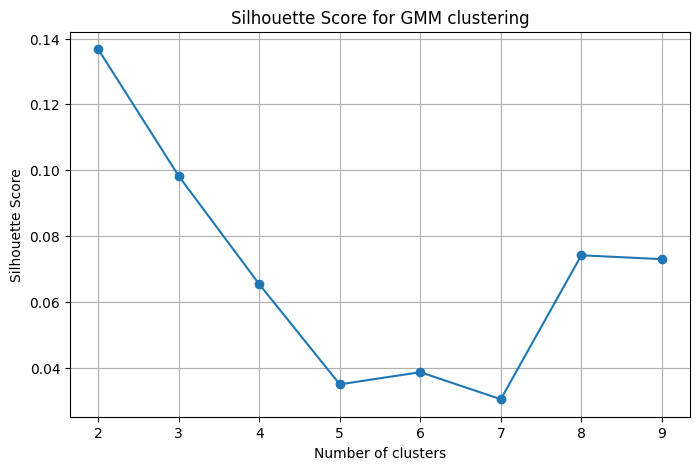

Optimal number of clusters according to Silhouette Score: 2


In [10]:
silhouette_scores = []
components_range = range(2, 10)  # від 2, бо silhouette не визначений для 1 кластеру

for n in components_range:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(unit_vectors)
    labels = gmm.predict(unit_vectors)
    score = silhouette_score(unit_vectors, labels)
    silhouette_scores.append(score)

# Побудова графіку
plt.figure(figsize=(8, 5))
plt.plot(components_range, silhouette_scores, marker='o')
plt.title("Silhouette Score for GMM clustering")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Вивід найкращого числа кластерів
optimal_n = components_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters according to Silhouette Score: {optimal_n}")

gmm = GaussianMixture(n_components=5, random_state=0)
gmm.fit(embeddings)
labels = gmm.predict(embeddings)



[np.float64(15.02465793155371), np.float64(6.6776257473572045), np.float64(3.7561644828884275), np.float64(2.4039452690485934), np.float64(1.6694064368393011), np.float64(1.226502688290099), np.float64(0.9390411207221069), np.float64(0.7419584163730227), np.float64(0.6009863172621484)]


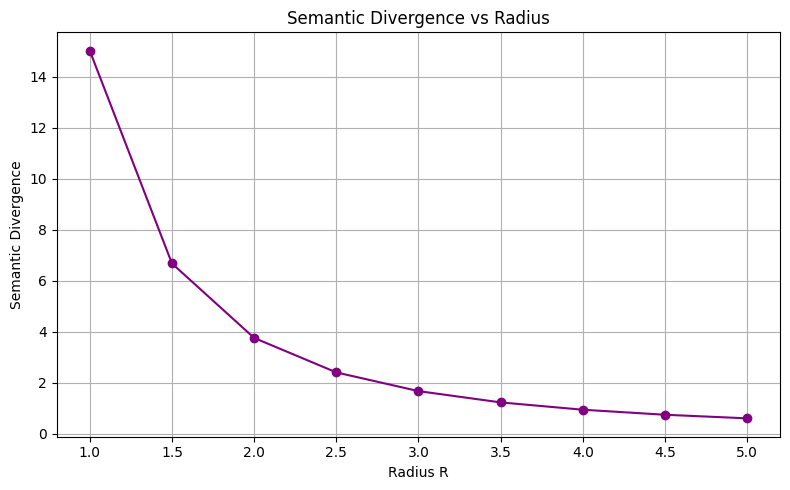

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import re

def clean_text(text):
    # Мінімальна очистка: залишаємо лише слова
    words = re.findall(r'\b\w+\b', text.lower())
    return " ".join(words)

def compute_semantic_flux(R=1.0):
    centroid = np.mean(unit_vectors, axis=0)
    
    distances = np.linalg.norm(unit_vectors - centroid, axis=1)
    
    surface_area = 4 * np.pi * (R ** 2)
    semantic_force = np.sum(distances) / surface_area
    
    return semantic_force

def plot_divergence_vs_radius(text, model_name='sentence-transformers/LaBSE', r_start=1, r_end=5, r_step=0.5):
    model = SentenceTransformer(model_name)

    radii = np.arange(r_start, r_end + r_step, r_step)
    divergences = [compute_semantic_flux(R=r) for r in radii]
    print(divergences)

    plt.figure(figsize=(8, 5))
    plt.plot(radii, divergences, marker='o', color='purple')
    plt.title("Semantic Divergence vs Radius")
    plt.xlabel("Radius R")
    plt.ylabel("Semantic Divergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_divergence_vs_radius(text)


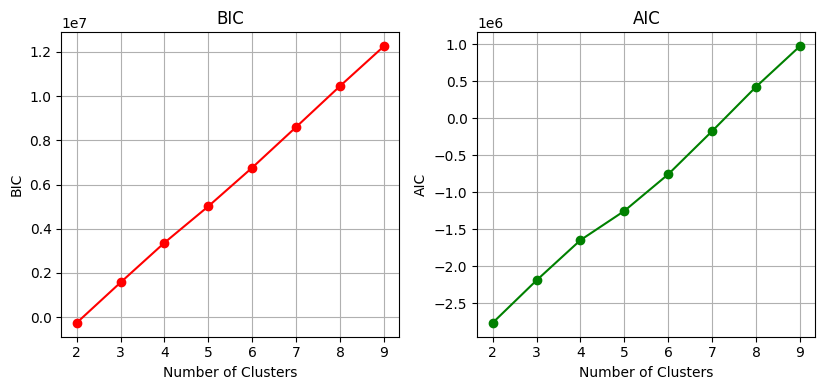

In [12]:
bic_scores = []
aic_scores = []

for n in components_range:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(unit_vectors)
    bic_scores.append(gmm.bic(unit_vectors))
    aic_scores.append(gmm.aic(unit_vectors))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))


# BIC (нижче - краще)
plt.subplot(1,3,2)
plt.plot(components_range, bic_scores, marker='o', color='red')
plt.title('BIC')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC')
plt.grid(True)

# AIC (нижче - краще)
plt.subplot(1,3,3)
plt.plot(components_range, aic_scores, marker='o', color='green')
plt.title('AIC')
plt.xlabel('Number of Clusters')
plt.ylabel('AIC')
plt.grid(True)

plt.tight_layout()
plt.show()
